In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# What changes when the update must be low rank?

Chapter 9 · Day 14

Compare full updates with rank-four Q/V adapters at a fixed microscopic recipe. A matched learning rate is a control, not proof it is each method's best setting.

Use the cycle: prediction → inspect mechanism → change one choice → interpret limits. Runnable reference answers follow each question. All computations use CPU; no model download or server is started.

In [2]:
from pathlib import Path
import sys
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/dongxi_llms").is_dir())
sys.path.insert(0, str(root / "src"))
import math, copy, json
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "font.size": 11})
from dongxi_llms import evaluation_lab as ev
from dongxi_llms import instruction_data_lab as data
from dongxi_llms import sft_lab as sft
def show_flow(labels, focus):
    fig, ax = plt.subplots(figsize=(11, 1.9))
    for i, label in enumerate(labels):
        ax.text(i, .5, label, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=.45", fc="#dce9f5" if i == focus else "#f6f6f6", ec="#666"))
        if i: ax.annotate("", (i-.25,.5), (i-.75,.5), arrowprops=dict(arrowstyle="->",color="#555"))
    ax.set_xlim(-.6,len(labels)-.4); ax.set_ylim(0,1); ax.axis("off")
    ax.set_title("Schematic process: highlighted component is this lesson's focus")
    plt.show()


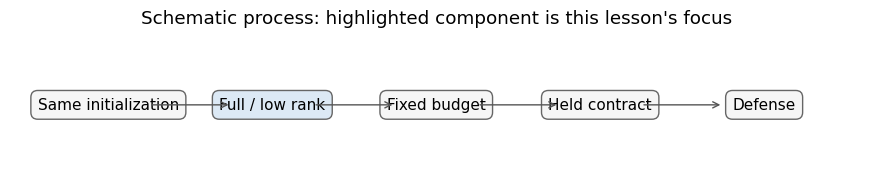

In [3]:
show_flow(["Same initialization","Full / low rank","Fixed budget","Held contract","Defense"], 1)

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 full sft lora and recipe defense: reference plot 01](../figures/chapter-09/day-14-01_full_sft_lora_and_recipe_defense-01.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

## Predict 1

With zero B and random A, predict which LoRA matrix receives a first-step gradient.

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

B receives signal through A. A's derivative includes B and is initially zero. The frozen base has no parameter gradient.

In [4]:
layer=sft.LoRALinear(torch.nn.Linear(6,5,bias=False),rank=2,alpha=2)
torch.manual_seed(1414); x=torch.randn(3,6)
assert torch.equal(layer(x),layer.base(x))
layer(x).sum().backward()
print("A gradient:",float(layer.a.grad.norm()),"B gradient:",float(layer.b.grad.norm()))
assert layer.a.grad.norm()==0 and layer.b.grad.norm()>0 and layer.base.weight.grad is None
with torch.no_grad(): layer.b.add_(.1)
torch.testing.assert_close(layer(x),torch.nn.functional.linear(x,layer.merged_weight()))

A gradient: 0.0 B gradient: 0.10943981260061264


## Predict 2

Predict the relative parameter counts. Must fewer trainable parameters imply a smaller whole model or the same training quality?

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

Adapter state is small, but base weights remain stored and activations remain needed. Quality depends on the constrained update and recipe; measure this fixture rather than presupposing a winner.

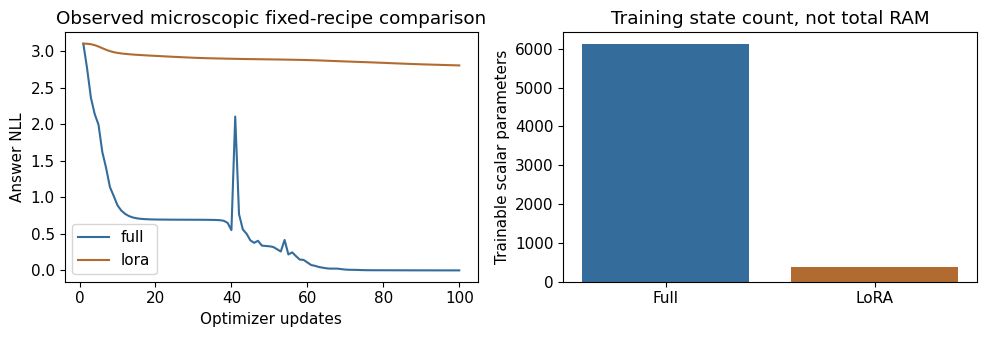

{'full': {'final_loss': 0.0005545320454984903, 'fixture_sequence_exact_match': 1.0, 'trainable_parameters': 6120, 'total_parameters': 6120}, 'lora': {'final_loss': 2.802457332611084, 'fixture_sequence_exact_match': 0.75, 'trainable_parameters': 384, 'total_parameters': 6504}}


In [5]:
_,full=sft.bounded_run(100,mode="full")
_,lora=sft.bounded_run(100,mode="lora")
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for result,color in [(full,"#346c9c"),(lora,"#b16b31")]:
    axes[0].plot(np.arange(1,101),result["history"],label=result["mode"],color=color)
axes[0].set(xlabel="Optimizer updates",ylabel="Answer NLL",title="Observed microscopic fixed-recipe comparison"); axes[0].legend()
axes[1].bar(["Full","LoRA"],[full["trainable_parameters"],lora["trainable_parameters"]],color=["#346c9c","#b16b31"])
axes[1].set(ylabel="Trainable scalar parameters",title="Training state count, not total RAM")
plt.tight_layout(); plt.show()
print({r["mode"]:{k:r[k] for k in ("final_loss","fixture_sequence_exact_match","trainable_parameters","total_parameters")} for r in (full,lora)})

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 full sft lora and recipe defense: reference plot 02](../figures/chapter-09/day-14-01_full_sft_lora_and_recipe_defense-02.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

## Predict 3

How would you defend a real model comparison without confusing optimizer updates, token exposure and wall time?

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

Choose one primary budget, freeze data/evaluation and record the other quantities. Compare both fixed settings and any separately declared tuning budget; run a larger transfer check only after health and regression gates pass.

In [6]:
proposal={"model":"Qwen/Qwen3-0.6B-Base","revision":"must be exact 40-character commit before execution",
          "primary_budget":"same supervised target exposure","controlled":["split","template","mask","seed policy"],
          "reported":["updates","runtime","peak memory","trainable count"],
          "larger_transfer_gate":["finite state","termination stable","held-out improvements","regression bounds"]}
print(json.dumps(proposal,indent=2))

{
  "model": "Qwen/Qwen3-0.6B-Base",
  "revision": "must be exact 40-character commit before execution",
  "primary_budget": "same supervised target exposure",
  "controlled": [
    "split",
    "template",
    "mask",
    "seed policy"
  ],
  "reported": [
    "updates",
    "runtime",
    "peak memory",
    "trainable count"
  ],
  "larger_transfer_gate": [
    "finite state",
    "termination stable",
    "held-out improvements",
    "regression bounds"
  ]
}


## Reading the evidence

The figures are regenerated from the current lesson tensors or declared fixture. Axes and counts define the comparison. Change one control, rerun the relevant cell, and explain what changed in the mechanism. Separate a verified implementation property from a claim about a real language model.

Return to the corresponding chapter and worked solution for the complete argument.